In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Dropout, BatchNormalization, Activation, Concatenate, LSTM, Bidirectional

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from tensorflow.keras.losses import CategoricalCrossentropy

In [2]:
x_url = 'X_rank3_tensor.npy'
y_url = 'y_labels.npy'
x_raw = np.load(x_url)
y_raw = np.load(y_url)

x_raw.shape

(1765, 60, 10)

In [3]:
track_features = [
    'tempo', 'loudness', 'mode', 'danceability', 'energy',
    'speechiness', 'acousticness', 'liveness', 'happiness', 'instrumentalness'
]

# mode를 제외한 나머지는 수치형
# mode는 원핫인코딩 필요하므로 따로 분리
# 영향이 가장 적은 instrumentalness 특성 제거
numeric_features = [f for f in track_features if f != 'mode' and f != 'instrumentalness']
categorical_feature = ['mode']


In [4]:
# 1. 데이터셋 분리
# 학습 데이터와 테스트 데이터로 분리
# mbti 별 비율이 동일하도록 startify 사용
x_train, x_test, y_train, y_test = train_test_split(
    x_raw, y_raw, test_size=0.2, random_state=42, shuffle=True, stratify=y_raw)

In [5]:
# 2. 전처리 함수 정의
# train 과 test 데이터 따로 전처리 사용하는 if문 로직은 Gemini 도움을 받음
# k-fold 적용을 위해 scaler, encoder도 매개변수로 받음

def data_preprocessed(x_data, scaler, encoder, is_train=False):
	(n_playlists, n_tracks, n_features) = x_data.shape
	x_2d = x_data.reshape(n_playlists*n_tracks, n_features)
	x_df = pd.DataFrame(x_2d, columns=track_features)

# 패딩된 노래는 tempo가 0값을 갖는 점을 이용
	real_song = x_df['tempo'] > 0

	# 수치형 데이터 전처리
	if is_train:
		scaler.fit(x_df.loc[real_song, numeric_features])

	x_df.loc[real_song, numeric_features] = scaler.transform(
		x_df.loc[real_song, numeric_features]
	)

	# 범주형 데이터 'mode' 전처리
	if is_train:
		encoder.fit(x_df.loc[real_song, categorical_feature])

	# 전체 변환, 패딩된 노래는 [0,0]
	mode_encoded = encoder.transform(x_df[categorical_feature])
	mode_encoded[~real_song] = 0

  # 수치형 데이터와 'mode' 결합
	x_numeric = x_df[numeric_features].values
	x_2d = np.concatenate([x_numeric, mode_encoded], axis=1)

	# 2d 배열을 다시 3d로 변환
	n_features = x_2d.shape[1]
	x_data = x_2d.reshape(n_playlists, n_tracks, n_features)

	return x_data

In [6]:
# LSTM, Dual input, RoandomForest, label smoothing, reduce LR은 Gemini의 코드를 차용했습니다
# 가장 확률 높은 3가지 유형 중에 정답이 있는지 여부를 확인하기 위해 top-3_acc도 출력


# -------------------------------------------------------
# 1. 중요 특성 5개 선정 및 보조 데이터 생성 함수
# -------------------------------------------------------
def prepare_dual_inputs(x_train, y_train, x_val, feature_names):
    # 1) 학습 데이터의 평균치 만들기
    #    (60곡의 평균값을 계산하여 (N, 10) 형태로 만듦)
    x_train_mean = x_train.mean(axis=1)
    x_val_mean = x_val.mean(axis=1)

    # y가 원핫인코딩 상태이면 정수로 변환
    # RandomForest 사용하기 위해
    y_int = np.argmax(y_train, axis=1) if y_train.ndim > 1 else y_train

    # 2) 중요 특성 Top 5 추출 (SHAP 대용, 훨씬 빠름)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(x_train_mean, y_int)

    importances = rf.feature_importances_
    top5_indices = np.argsort(importances)[::-1][:5] # 상위 5개 인덱스

    print(f"✅ 선정된 중요 특성 Top 5: {[feature_names[i] for i in top5_indices]}")

    # 3) 선택된 5개 특성만 뽑아서 보조 입력(Input 2) 생성
    x_train_static = x_train_mean[:, top5_indices] # (N, 5)
    x_val_static = x_val_mean[:, top5_indices]     # (N, 5)

    return x_train_static, x_val_static

# -------------------------------------------------------
# 2. Dual-Input 모델 정의 (Functional API)
# -------------------------------------------------------
def build_dual_input_model(seq_shape, static_shape):
    # Input 1: 기존과 같은 시퀀스 데이터
    input_seq = Input(shape=seq_shape, name='seq_input')

    x1 = Conv1D(64, 3, padding='same')(input_seq)
    x1 = BatchNormalization()(x1)
    x1 = Activation('relu')(x1)
    x1 = MaxPooling1D(2)(x1)
    x1 = Dropout(0.3)(x1)

    x1 = Bidirectional(LSTM(64))(x1) # LSTM으로 변경
    x1 = Dropout(0.4)(x1)

    # input2 : 5가지 중요 특성 요약 데이터
    input_static = Input(shape=static_shape, name='static_input')

    x2 = Dense(32, activation='relu')(input_static)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.2)(x2)

    # 두 정보 병합
    merged = Concatenate()([x1, x2])

    # --- 분류기 ---
    dense = Dense(64, activation='relu')(merged)
    output = Dense(16, activation='softmax')(dense)

    loss_fn = CategoricalCrossentropy(label_smoothing=0.1) # label smoothing 적용
    model = Model(inputs=[input_seq, input_static], outputs=output)

    model.compile(optimizer='adam',
                  loss=loss_fn,
                  metrics=['accuracy', TopKCategoricalAccuracy(k=3, name='top3_acc')])
    return model

# 최적 에포크 찾기 위한 early_stopping 정의
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # 정체되면 학습률을 절반으로 뚝 떨어뜨림
    patience=5,       # 5번
    min_lr=1e-6,
    verbose=0
)


In [7]:
# 클래스 별 불균형을 고려한 Stratified K-Fold 적용

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
target_encoder = OneHotEncoder(sparse_output=False)
target_encoder.fit(y_train.reshape(-1, 1))

all_y_true = [] # 실제 mbti 정답 저장
all_y_pred = [] # 예측된 mbti 저장
fold_scores = [] # 각 폴드 별 점수 저장
fold_models = [] # 각 폴드 별 모델 저장

for fold, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train)):
    print(f" 📁 {fold+1}번째 폴드 훈련중")

    x_train_partial, x_val = x_train[train_idx], x_train[val_idx]
    y_train_partial, y_val = y_train[train_idx], y_train[val_idx]

    # 기본 전처리
    scaler = StandardScaler()
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    x_train_partial = data_preprocessed(x_train_partial, scaler, encoder, is_train=True)
    x_val = data_preprocessed(x_val, scaler, encoder, is_train=False)


    y_train_encoded = target_encoder.transform(y_train_partial.reshape(-1, 1))
    y_val_encoded = target_encoder.transform(y_val.reshape(-1, 1))

    # Dual Input 준비 (Input 2 생성)
    # 전처리된 데이터에서 통계적 중요 특성을 추출해 별도 입력으로 만듦
    temp_features = ['tempo', 'loudness', 'danceability', 'energy',
    'speechiness', 'acousticness', 'liveness', 'happiness', 'mode0', 'mode1']
    x_train_static, x_val_static = prepare_dual_inputs(x_train_partial, y_train_encoded, x_val, temp_features)

    # 모델 빌드
    model = build_dual_input_model(
        seq_shape=(60, x_train_partial.shape[2]),
        static_shape=(5,) # 5개 중요 특성
    )

    # 학습 (입력을 2개 리스트로 전달)
    history = model.fit(
        [x_train_partial, x_train_static], y_train_encoded,
        validation_data=([x_val, x_val_static], y_val_encoded),
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    # 현재 폴드의 예측 확률 계산
    val_pred = model.predict([x_val, x_val_static], verbose = 0)
    val_acc = accuracy_score(np.argmax(y_val_encoded, axis=1), np.argmax(val_pred, axis=1))

    # 확률 -> 정수 인덱스로 변환
    y_fold_pred = np.argmax(val_pred, axis=1)
    y_fold_true = np.argmax(y_val_encoded, axis=1)

    # 리스트에 저장
    all_y_true.append(y_fold_true)
    all_y_pred.append(y_fold_pred)

    fold_scores.append(val_acc)
    fold_models.append(model)

    # 검증
    results = model.evaluate([x_val, x_val_static], y_val_encoded, verbose=0)
    print(f"  -> 검증 정확도: {results[1]:.4f}")
    print(f"  -> Top-3  정확도: {results[2]:.4f}")


print("\n 평균 K-Fold 정확도: ", np.mean(fold_scores))

 📁 1번째 폴드 훈련중
✅ 선정된 중요 특성 Top 5: ['acousticness', 'speechiness', 'danceability', 'happiness', 'loudness']
  -> 검증 정확도: 0.4558
  -> Top-3  정확도: 0.6820
 📁 2번째 폴드 훈련중
✅ 선정된 중요 특성 Top 5: ['happiness', 'speechiness', 'acousticness', 'danceability', 'energy']
  -> 검증 정확도: 0.4558
  -> Top-3  정확도: 0.6608
 📁 3번째 폴드 훈련중
✅ 선정된 중요 특성 Top 5: ['happiness', 'speechiness', 'acousticness', 'danceability', 'energy']
  -> 검증 정확도: 0.4397
  -> Top-3  정확도: 0.6915
 📁 4번째 폴드 훈련중
✅ 선정된 중요 특성 Top 5: ['happiness', 'acousticness', 'speechiness', 'danceability', 'energy']
  -> 검증 정확도: 0.4787
  -> Top-3  정확도: 0.7092
 📁 5번째 폴드 훈련중
✅ 선정된 중요 특성 Top 5: ['speechiness', 'happiness', 'acousticness', 'danceability', 'loudness']
  -> 검증 정확도: 0.4894
  -> Top-3  정확도: 0.7624

 평균 K-Fold 정확도:  0.46389243916497513


시각화

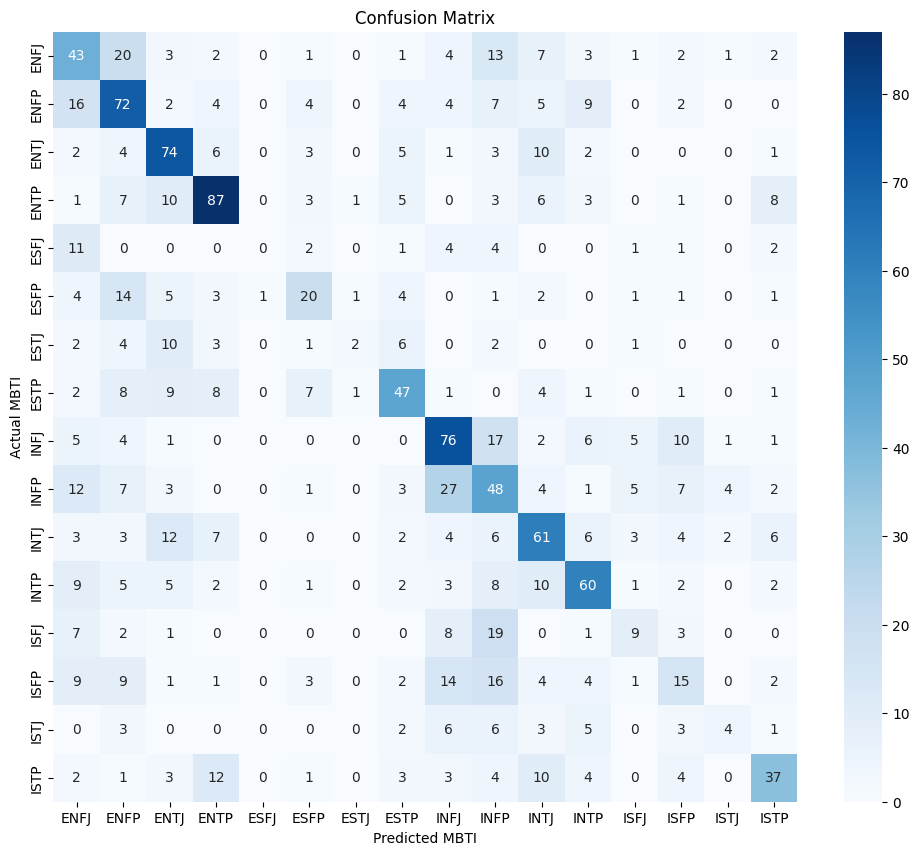

In [8]:
# 각 폴드별 예측 시각화
# Gemini 코드 차용

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# 전체 데이터 하나로 합치기
final_y_true = np.concatenate(all_y_true)
final_y_pred = np.concatenate(all_y_pred)

# mbti 라벨 이름 가져오기
labels = target_encoder.categories_[0]

# 오차 행렬 계산
cm = confusion_matrix(final_y_true, final_y_pred)

# 시각화 (Heatmap 그리기)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted MBTI')
plt.ylabel('Actual MBTI')
plt.title('Confusion Matrix')
plt.show()

# **테스트 섹션(Gemini 코드 차용)**

In [9]:
# 최적의 모델 선택
best_idx = int(np.argmax(fold_scores))
best_model = fold_models[best_idx]

# 최적의 학습 데이터 찾기
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train)):
  if fold_idx == best_idx:
    x_train_best = x_train[train_idx]
    y_train_best = y_train[train_idx]
    break

# Scaler, encoder 초기화 후 최적 데이터로 다시 fit
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
x_train_best = data_preprocessed(x_train_best, scaler, encoder, is_train=True)

# target_encoder 도 실행
target_encoder = OneHotEncoder(sparse_output=False)
target_encoder.fit(y_train_best.reshape(-1, 1))

# Top 5 특성도 다시 찾기
x_train_best_mean = x_train_best.mean(axis=1)

y_train_best_int = np.argmax(y_train_best, axis=1) if y_train_best.ndim > 1 else y_train_best


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_best_mean, y_train_best_int)

# Top 5 index
importances = rf.feature_importances_
top5_best_indices = np.argsort(importances)[::-1][:5]

temp_features = ['tempo', 'loudness', 'danceability', 'energy',
    'speechiness', 'acousticness', 'liveness', 'happiness', 'mode0', 'mode1']
print(f"✅ 선정된 중요 특성 Top 5: {[temp_features[i] for i in top5_best_indices]}")

✅ 선정된 중요 특성 Top 5: ['speechiness', 'happiness', 'acousticness', 'danceability', 'loudness']


In [10]:
# 최종 테스트 데이터 평가

# x,y 데이터 전처리
x_test = data_preprocessed(x_test, scaler, encoder, is_train=False)
y_test = target_encoder.transform(y_test.reshape(-1, 1))

# 테스트 데이터의 static 생성
x_test_mean = x_test.mean(axis=1)
x_test_static = x_test_mean[:, top5_best_indices]

# 모델 평가
test_results = best_model.evaluate([x_test, x_test_static], y_test, verbose=0)
print(f"테스트 정확도: {test_results[1]:.4f}")
print(f"테스트 Top-3 정확도: {test_results[2]:.4f}")

테스트 정확도: 0.4363
테스트 Top-3 정확도: 0.7110


테스트 데이터에 대한 시각화(Gemini 코드 차용)

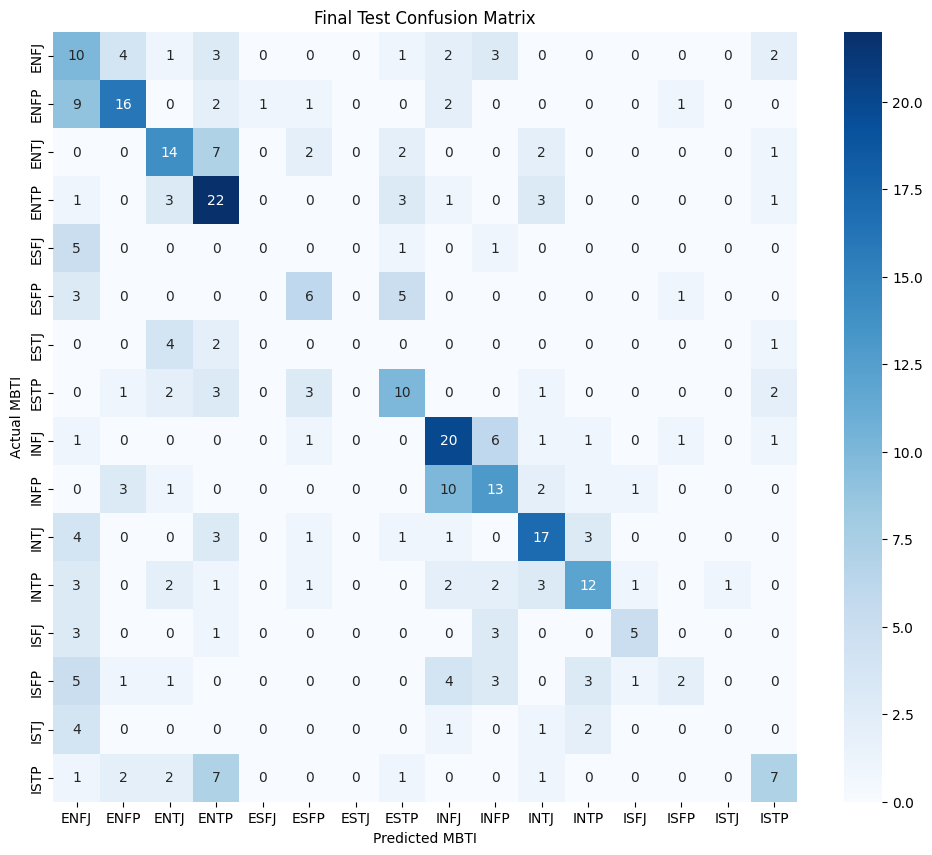

In [11]:
y_test_pred = best_model.predict([x_test, x_test_static], verbose=0)

# 확률 -> 정수 인덱스로 변환
y_test_pred = np.argmax(y_test_pred, axis=1)
y_test_true = np.argmax(y_test, axis=1)

# mbti 라벨 이름 가져오기
labels = target_encoder.categories_[0]

# 오차 행렬 계산
cm = confusion_matrix(y_test_true, y_test_pred)

# 시각화 (Heatmap 그리기)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted MBTI')
plt.ylabel('Actual MBTI')
plt.title('Final Test Confusion Matrix')
plt.show()